<a href="https://colab.research.google.com/github/hdpark1208/StudyCode/blob/main/Algorithm/BJ/%EB%B1%80%2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 뱀

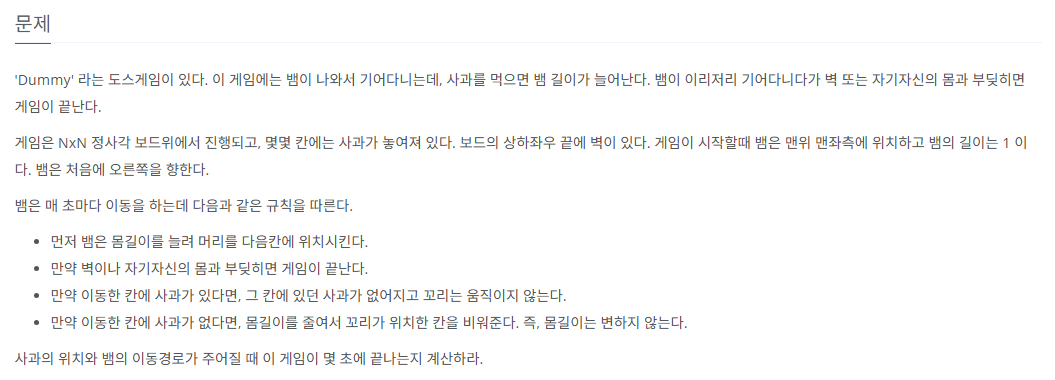

## 입력 출력 및 예제


* 입력

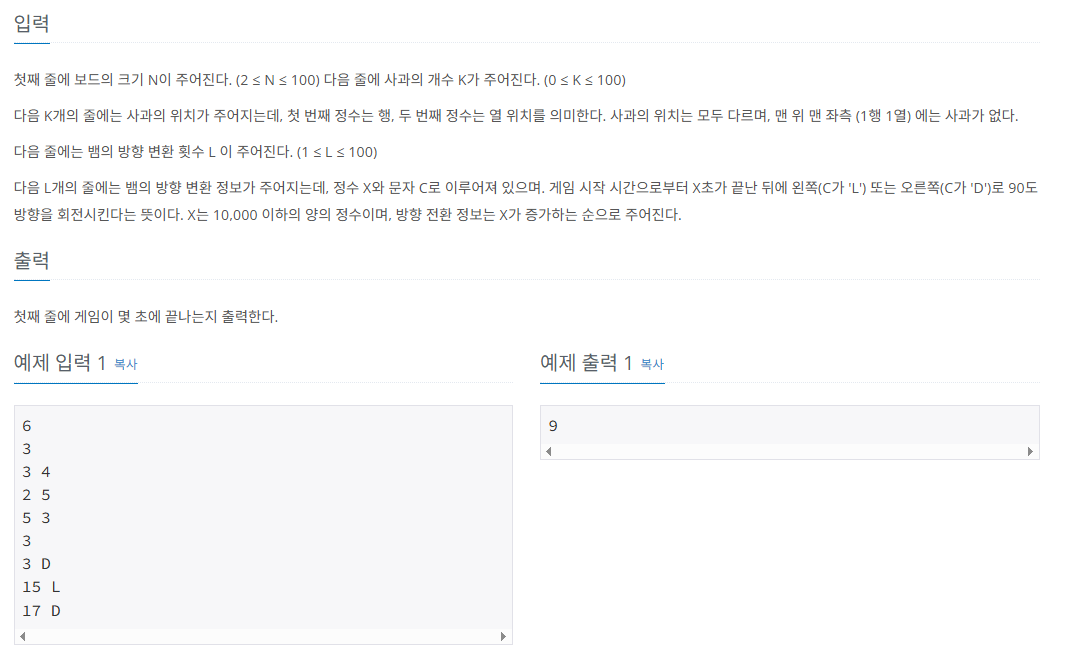

* 출력

* 예제

## 구상

*

## 코드

In [ ]:
from collections import deque
N = int(input())
K = int(input())

board = [[0] * N for _ in range(N)]

for _ in range(K):
    x, y = map(int, input().split())
    board[x - 1][y - 1] = 1

L = int(input())

snake_move = [] # (초(t), 방향(L or D))

dirs = [(0, 1), (1, 0), (0, -1), (-1, 0)] # 우,하,좌,상

for _ in range(L):
    snake_move.append(tuple(input().split()))


snake = deque([(0, 0)])
snake_move = deque(snake_move)
angle = 0
t = 1
while t > 0:
    x, y = snake[-1] # 뱀 머리
    nx = x + dirs[angle % 4][0]
    ny = y + dirs[angle % 4][1]

    if nx < 0 or nx > (N - 1) or ny < 0 or ny > (N - 1):
        break
    if (nx, ny) in snake:
        break

    if board[nx][ny] == 1:
        board[nx][ny] = 0
        snake.append((nx, ny))
    else:
        snake.append((nx, ny))
        snake.popleft()

    if snake_move and int(snake_move[0][0]) == t:
        s, dir = snake_move.popleft()

        if dir == 'L':
            angle -= 1
        else:
            angle += 1

    t += 1

print(t)

3
0
4
1 D
2 D
3 D
4 D
7


In [ ]:
# GPT (틀림)
from collections import deque
import sys

input = sys.stdin.readline

N = int(input())
K = int(input())

board = [[0] * N for _ in range(N)]
for _ in range(K):
    x, y = map(int, input().split())
    board[x - 1][y - 1] = 1

L = int(input())
turns = deque()
for _ in range(L):
    X, C = input().split()
    turns.append((int(X), C))

# 우 하 좌 상
dirs = [(0, 1), (1, 0), (0, -1), (-1, 0)]
d = 0

snake = deque([(0, 0)])   # 왼쪽이 꼬리, 오른쪽이 머리
body = {(0, 0)}           # 몸 위치 빠른 확인용

time = 0

while True:
    time += 1

    hx, hy = snake[-1]
    nx = hx + dirs[d][0]
    ny = hy + dirs[d][1]

    # 1. 벽 충돌
    if not (0 <= nx < N and 0 <= ny < N):
        break

    # 2. 자기 몸 충돌 검사
    if board[nx][ny] == 0:
        # 사과가 없으면 꼬리가 먼저 빠질 예정
        tx, ty = snake[0]

        # 꼬리를 미리 제거한 상태로 충돌 검사
        body.remove((tx, ty))
        if (nx, ny) in body:
            break

        snake.popleft()
        snake.append((nx, ny))
        body.add((nx, ny))

    else:
        # 사과가 있으면 꼬리가 안 빠짐
        if (nx, ny) in body:
            break

        board[nx][ny] = 0
        snake.append((nx, ny))
        body.add((nx, ny))

    # 3. 방향 전환
    if turns and turns[0][0] == time:
        _, c = turns.popleft()
        if c == 'L':
            d = (d - 1) % 4
        else:
            d = (d + 1) % 4

print(time)

In [ ]:
# GPT 2 (틀림)
from collections import deque

N = int(input())
K = int(input())

board = [[0] * N for _ in range(N)]
for _ in range(K):
    x, y = map(int, input().split())
    board[x - 1][y - 1] = 1

L = int(input())
moves = deque()
for _ in range(L):
    t, c = input().split()
    moves.append((int(t), c))

dirs = [(0, 1), (1, 0), (0, -1), (-1, 0)]  # 우 하 좌 상
d = 0
time = 0

snake = deque([(0, 0)])

while True:
    time += 1

    x, y = snake[-1]
    nx = x + dirs[d][0]
    ny = y + dirs[d][1]

    if not (0 <= nx < N and 0 <= ny < N):
        break

    # 사과가 없는 경우에는 꼬리가 빠질 예정이므로,
    # 현재 꼬리 칸으로 가는 것은 허용될 수 있음
    if board[nx][ny] == 0:
        tail = snake[0]
        if (nx, ny) in snake and (nx, ny) != tail:
            break
        snake.append((nx, ny))
        snake.popleft()
    else:
        if (nx, ny) in snake:
            break
        board[nx][ny] = 0
        snake.append((nx, ny))

    if moves and moves[0][0] == time:
        _, c = moves.popleft()
        if c == 'L':
            d = (d - 1) % 4
        else:
            d = (d + 1) % 4

print(time)

### 메모



* 디큐로 뱀의 상태를 관리했다
* 이동한 곳에 사과를 있을 때는 디큐에 사과먹은 좌표를 넣어주고, 없을 때는 사과먹은 좌표를 넣어주고, 디큐에 popleft()를 한다. 이동한 곳에 머리 좌표를 넣어주고 꼬리를 땡겨줘서 길이를 똑같이 유지한다는 느낌.